# Task 2 — MLE for the Binomial Distribution

We have $X_1, \ldots, X_n \overset{\text{iid}}{\sim} \text{Bin}(m, \theta)$ where $m$ is known and we want to estimate $\theta$.

## Finding the MLE

The log-likelihood is:

$$
\ell(\theta) = \text{const} + \left(\sum_{i=1}^n x_i\right)\log\theta + \left(mn - \sum_{i=1}^n x_i\right)\log(1-\theta)
$$

Setting the derivative to zero:

$$
\frac{d\ell}{d\theta} = \frac{\sum x_i}{\theta} - \frac{mn - \sum x_i}{1-\theta} = 0
\implies \hat{\theta} = \frac{\bar{X}}{m}
$$

The second derivative is negative everywhere on $(0,1)$, so this is indeed a maximum.

## Properties

Since $\mathbb{E}[X_i] = m\theta$, we get $\mathbb{E}[\hat{\theta}] = \theta$ — the estimator is unbiased.

Its variance follows from $\operatorname{Var}(X_i) = m\theta(1-\theta)$:

$$
\operatorname{Var}(\hat{\theta}) = \frac{\theta(1-\theta)}{mn}
$$

Because it's unbiased, $\text{MSE} = \operatorname{Var}(\hat{\theta})$. The estimator is also consistent (LLN) and asymptotically efficient — it achieves the Cramér–Rao bound in the limit.

## Experiment

We check the theoretical results numerically. For $m=4$, $\theta = 0.2$, we run $M = 2000$ simulations across several sample sizes and track how the estimates behave.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})

m, theta, M = 4, 0.2, 2000
ns  = [5, 10, 20, 50, 100, 300, 1000]
eps = 0.05
rng = np.random.default_rng(42)

results       = []
all_estimates = {}

for n in ns:
    samples   = rng.binomial(n=m, p=theta, size=(M, n))
    theta_hat = samples.mean(axis=1) / m
    error     = theta_hat - theta
    all_estimates[n] = theta_hat

    results.append({
        "n":             n,
        "mean error":    round(error.mean(), 6),
        "std error":     round(error.std(ddof=1), 6),
        "empirical MSE": round((error**2).mean(), 6),
        "theory MSE":    round(theta*(1-theta)/(m*n), 6),
        f"|err|>{eps} %": round(100*(np.abs(error) > eps).mean(), 2),
    })

res_df = pd.DataFrame(results).set_index("n")
print(res_df.to_string())

      mean error  std error  empirical MSE  theory MSE  |err|>0.05 %
n                                                                   
5      -0.000975   0.087887       0.007721    0.008000         59.45
10      0.001187   0.063218       0.003996    0.004000         44.70
20      0.000044   0.043993       0.001934    0.002000         26.90
50      0.000410   0.028257       0.000798    0.000800          7.50
100    -0.000614   0.020151       0.000406    0.000400          1.75
300     0.000155   0.011252       0.000127    0.000133          0.00
1000   -0.000054   0.006260       0.000039    0.000040          0.00


## Results

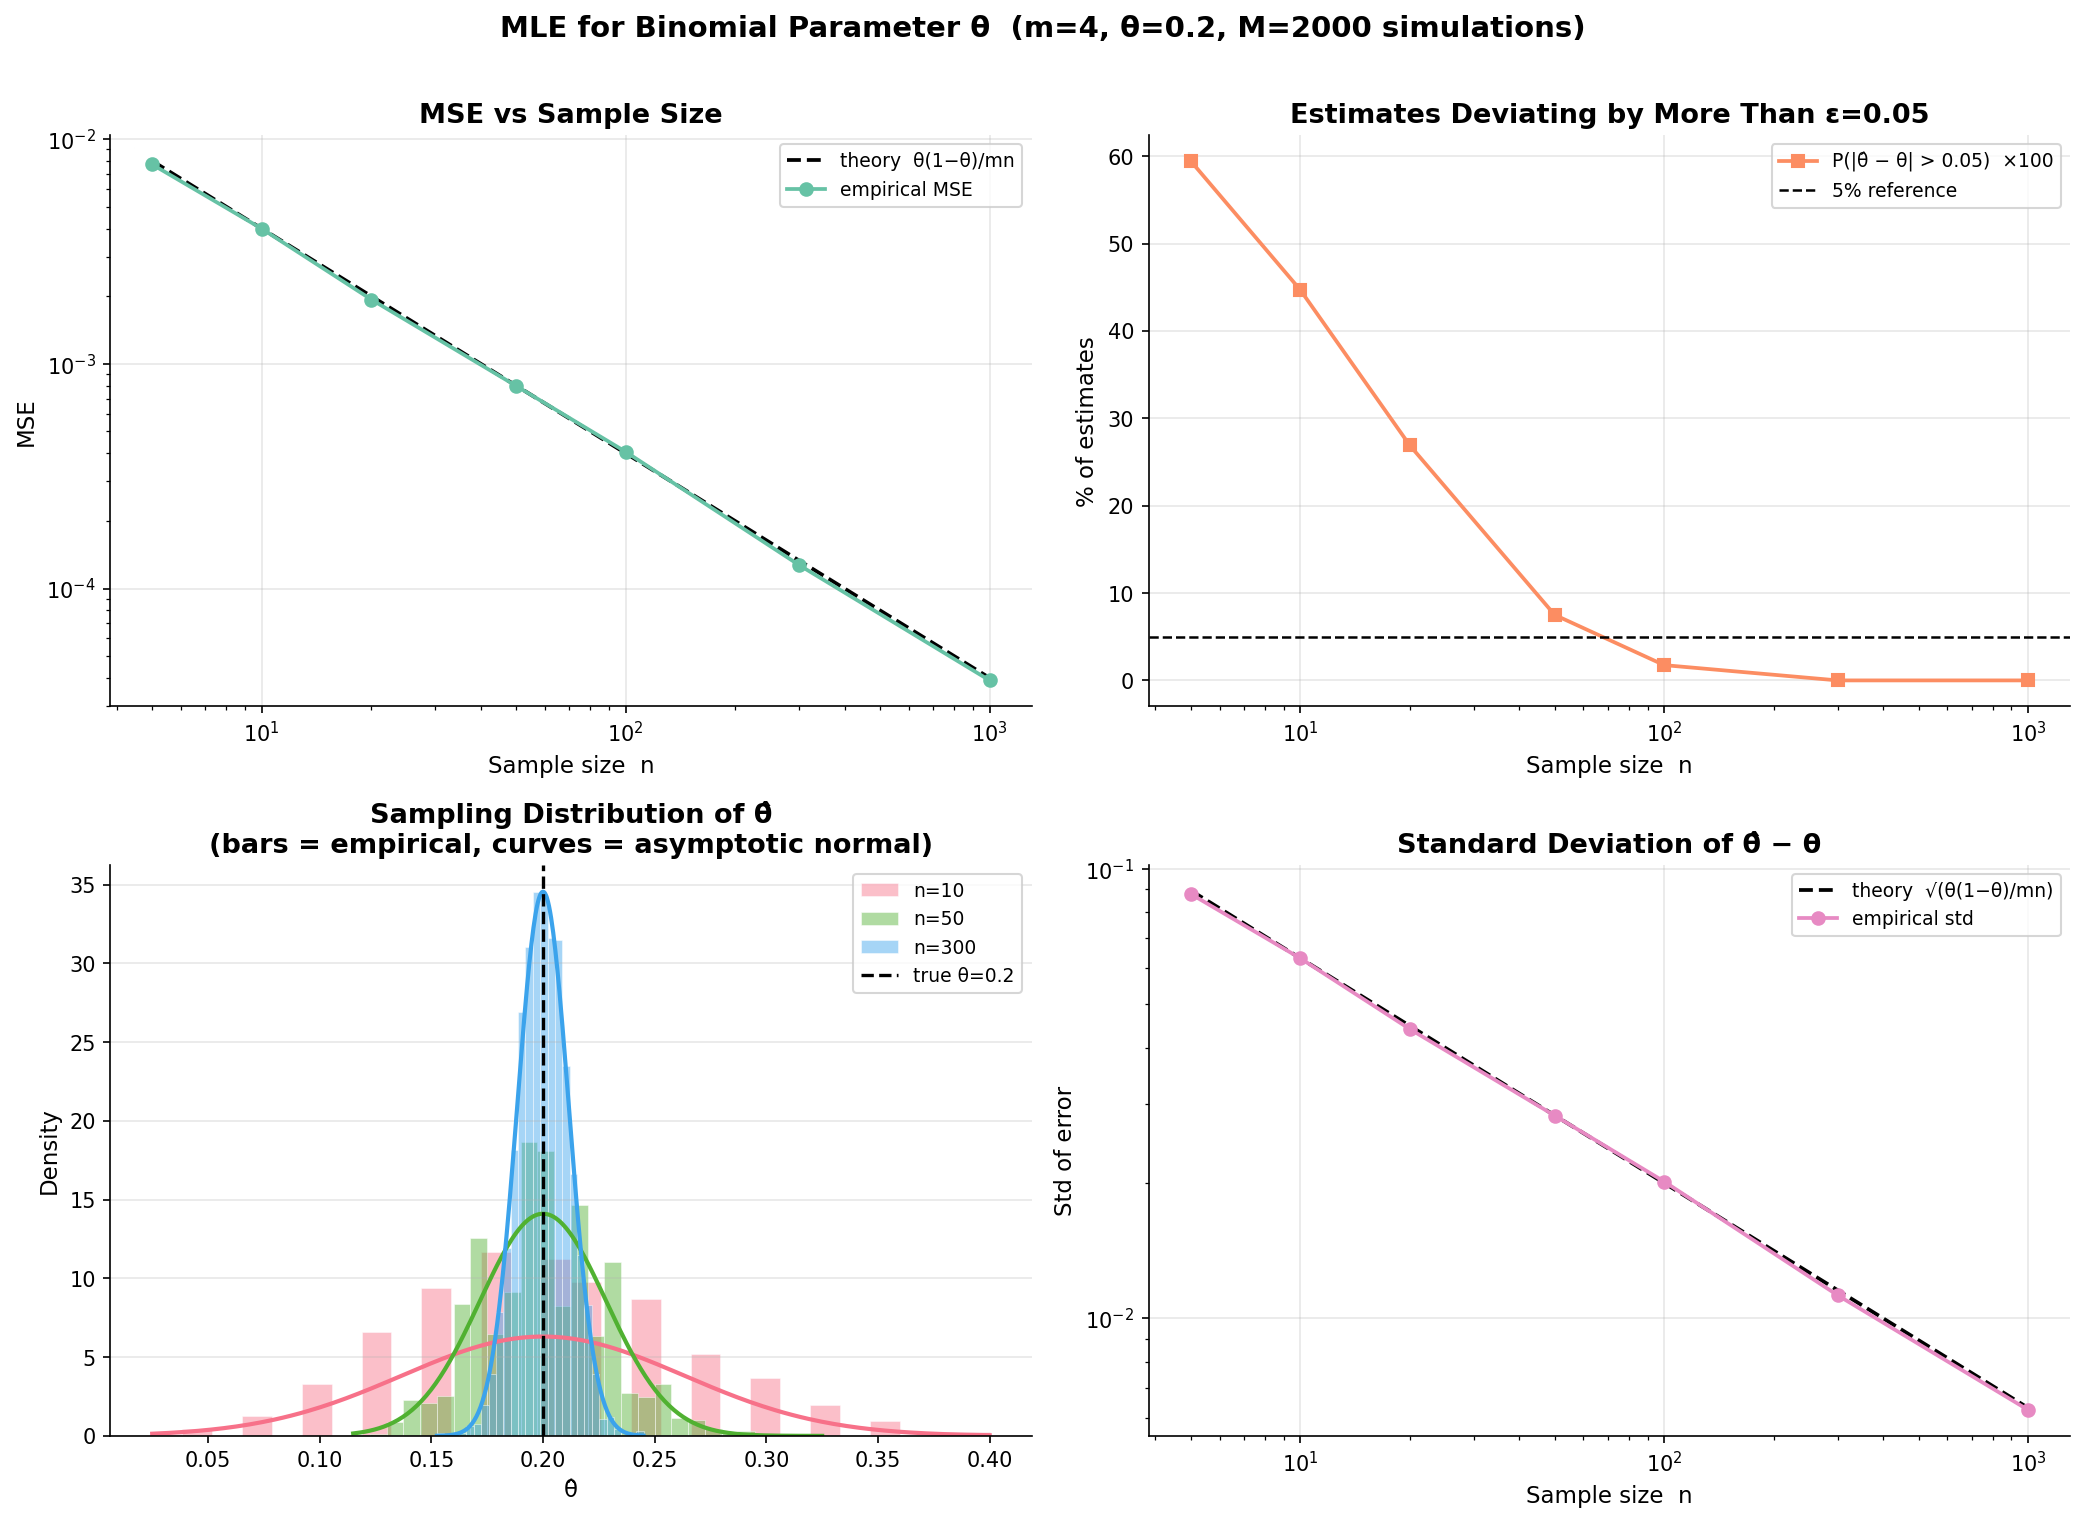

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MLE for Binomial Parameter θ  (m=4, θ=0.2, M=2000 simulations)",
             fontsize=14, fontweight="bold", y=1.01)

colors = sns.color_palette("Set2", len(ns))

# ── 1. MSE: empirical vs theory ──────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(ns, res_df["theory MSE"],    "k--", lw=1.8, label="theory  θ(1−θ)/mn")
ax.plot(ns, res_df["empirical MSE"], "o-",  lw=1.8, color=colors[0],
        label="empirical MSE", markersize=6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sample size  n")
ax.set_ylabel("MSE")
ax.set_title("MSE vs Sample Size")
ax.legend(fontsize=9)
ax.grid(True)

# ── 2. Fraction exceeding threshold ──────────────────────────────────────────
ax = axes[0, 1]
ax.plot(ns, res_df[f"|err|>{eps} %"], "s-", lw=1.8, color=colors[1],
        markersize=6, label=f"P(|θ̂ − θ| > {eps})  ×100")
ax.axhline(5, color="black", lw=1.2, ls="--", label="5% reference")
ax.set_xscale("log")
ax.set_xlabel("Sample size  n")
ax.set_ylabel("% of estimates")
ax.set_title(f"Estimates Deviating by More Than ε={eps}")
ax.legend(fontsize=9)
ax.grid(True)

# ── 3. Distribution of θ̂ at selected n ──────────────────────────────────────
ax = axes[1, 0]
selected = [10, 50, 300]
sel_colors = sns.color_palette("husl", len(selected))
for col, n in zip(sel_colors, selected):
    estimates = all_estimates[n]
    ax.hist(estimates, bins=28, density=True, alpha=0.45, color=col,
            edgecolor="white", linewidth=0.5, label=f"n={n}")
    # overlay normal approximation
    mu_t = theta
    sd_t = np.sqrt(theta*(1-theta)/(m*n))
    xs   = np.linspace(estimates.min(), estimates.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu_t, sd_t), color=col, lw=2)
ax.axvline(theta, color="black", lw=1.6, ls="--", label="true θ=0.2")
ax.set_xlabel("θ̂")
ax.set_ylabel("Density")
ax.set_title("Sampling Distribution of θ̂\n(bars = empirical, curves = asymptotic normal)")
ax.legend(fontsize=9)
ax.grid(axis="y")

# ── 4. Std of error vs 1/√n scaling ──────────────────────────────────────────
ax = axes[1, 1]
theory_std = np.sqrt([theta*(1-theta)/(m*n) for n in ns])
ax.plot(ns, theory_std,             "k--", lw=1.8, label="theory  √(θ(1−θ)/mn)")
ax.plot(ns, res_df["std error"], "o-",  lw=1.8, color=colors[3],
        markersize=6, label="empirical std")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sample size  n")
ax.set_ylabel("Std of error")
ax.set_title("Standard Deviation of θ̂ − θ")
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("../results/figures/task2_mle_binomial.png", bbox_inches="tight", dpi=180)
plt.show()

## Conclusions

The simulation confirms the theoretical results well. The empirical MSE matches the formula $\theta(1-\theta)/mn$ closely across all sample sizes. At small $n$ (5–20), more than a quarter of estimates deviate from the true value by more than 0.05, but this drops sharply — by $n=300$ it essentially never happens. The sampling distribution narrows and becomes increasingly symmetric around the true $\theta=0.2$ as $n$ grows, consistent with asymptotic normality.